In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib

DATA_PATH = '/content/drive/MyDrive/Dissertation/Data/phase2_features.parquet'
MODELS_FOLDER = '/content/drive/MyDrive/Dissertation/Models'

df = pd.read_parquet(DATA_PATH)
model_features = joblib.load(f'{MODELS_FOLDER}/model_features.pkl')

district_counts = df['postcode_district'].value_counts()
valid_districts = district_counts[district_counts >= 30].index

df_idx = df[df['postcode_district'].isin(valid_districts)].copy()

print(f"Total rows loaded: {len(df):,}")
print(f"Model features: {len(model_features)}")
print(f"Total postcode districts: {df['postcode_district'].nunique()}")
print(f"Districts with at least 30 sales: {len(valid_districts)}")
print(f"Rows retained after district filter: {len(df_idx):,}")

Mounted at /content/drive
Total rows loaded: 363,250
Model features: 18
Total postcode districts: 92
Districts with at least 30 sales: 89
Rows retained after district filter: 363,245


In [ ]:
df_idx['year_month'] = df_idx['sale_year'] * 12 + df_idx['sale_month']

monthly_ppsqm = (
    df_idx.groupby(['postcode_district', 'year_month'])['price_per_sqm']
    .median()
    .reset_index()
    .sort_values(['postcode_district', 'year_month'])
)

monthly_ppsqm['smoothed_ppsqm'] = (
    monthly_ppsqm.groupby('postcode_district')['price_per_sqm']
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).median())
)

reference_period = df_idx['year_month'].max()
ref_year = reference_period // 12
ref_month = reference_period % 12
if ref_month == 0:
    ref_month = 12
    ref_year -= 1
print(f"Reference period: {ref_year}-{ref_month:02d}")

adj_rows = []
for district in valid_districts:
    district_data = monthly_ppsqm[monthly_ppsqm['postcode_district'] == district].copy()
    district_data['distance_to_ref'] = (district_data['year_month'] - reference_period).abs()
    reference_value = district_data.loc[district_data['distance_to_ref'].idxmin(), 'smoothed_ppsqm']
    district_data['adj_factor'] = reference_value / district_data['smoothed_ppsqm']
    adj_rows.append(district_data[['postcode_district', 'year_month', 'adj_factor']])

adj_factor_table = pd.concat(adj_rows, ignore_index=True)

print(f"District-month combinations: {len(adj_factor_table):,}")
print(adj_factor_table['adj_factor'].describe())

Reference period: 2026-03
District-month combinations: 8,541
count    8541.000000
mean        1.192422
std         0.228646
min         0.546197
25%         1.021910
50%         1.153516
75%         1.345391
max         2.232245
Name: adj_factor, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

df_idx = df_idx.merge(adj_factor_table, on=['postcode_district', 'year_month'], how='left')
df_idx['adjusted_price'] = df_idx['price'] * df_idx['adj_factor']
df_idx['adjusted_log_price'] = np.log(df_idx['adjusted_price'])

print(f"Rows with missing adj_factor: {df_idx['adj_factor'].isna().sum()}")

df_idx = df_idx.dropna(subset=model_features + ['adjusted_log_price'])
print(f"Rows after dropping missing values: {len(df_idx):,}")

X = df_idx[model_features]
y = df_idx['adjusted_log_price']

X_train_adj, X_test_adj, y_train_adj, y_test_adj = train_test_split(
    X, y, test_size=0.2, random_state=42
)
test_adj_factors = df_idx.loc[X_test_adj.index, 'adj_factor']

print(f"Training rows: {len(X_train_adj):,}")
print(f"Test rows: {len(X_test_adj):,}")

xgb_model_adj = joblib.load(f'{MODELS_FOLDER}/xgb_model_adjusted.pkl')
print("Adjusted XGBoost model loaded successfully.")

Rows with missing adj_factor: 0
Rows after dropping missing values: 361,684
Training rows: 289,347
Test rows: 72,337
Adjusted XGBoost model loaded successfully.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

n_bootstrap = 500
epc_coefficients = []
epc_index = model_features.index('epc_numeric')

for i in range(n_bootstrap):
    X_resampled, y_resampled = resample(X_train_adj, y_train_adj, random_state=i)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=10.0))
    ])
    pipeline.fit(X_resampled, y_resampled)
    epc_coefficients.append(pipeline.named_steps['ridge'].coef_[epc_index])

epc_coefficients = np.array(epc_coefficients)
ci_low, ci_high = np.percentile(epc_coefficients, [2.5, 97.5])
mean_effect_pct = (np.exp(epc_coefficients.mean()) - 1) * 100
ci_low_pct = (np.exp(ci_low) - 1) * 100
ci_high_pct = (np.exp(ci_high) - 1) * 100

print(f"Mean EPC effect: {mean_effect_pct:.2f}% per band")
print(f"95% confidence interval: [{ci_low_pct:.2f}%, {ci_high_pct:.2f}%]")

Mean EPC effect: 0.02% per band
95% confidence interval: [-0.13%, 0.17%]


In [ ]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

epc_index = model_features.index('epc_numeric')

alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
print("EPC effect at different alpha values:")
for alpha in alphas_to_test:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train_adj)
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_scaled, y_train_adj)
    coef = ridge_model.coef_[epc_index]
    pct_effect = (np.exp(coef) - 1) * 100
    print(f"  alpha={alpha:>6}: {pct_effect:.3f}% per band")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_adj)
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5)
ridge_cv.fit(X_scaled, y_train_adj)
cv_coef = ridge_cv.coef_[epc_index]
cv_pct = (np.exp(cv_coef) - 1) * 100
print(f"\nCross-validated best alpha: {ridge_cv.alpha_:.4f}")
print(f"EPC effect at that alpha: {cv_pct:.3f}% per band")

EPC effect at different alpha values:
  alpha=  0.01: 0.014% per band
  alpha=   0.1: 0.014% per band
  alpha=   1.0: 0.014% per band
  alpha=  10.0: 0.014% per band
  alpha= 100.0: 0.016% per band

Cross-validated best alpha: 7.1969
EPC effect at that alpha: 0.014% per band


In [ ]:
features_without_lag = [f for f in model_features if f != 'spatial_lag_price']
epc_index_no_lag = features_without_lag.index('epc_numeric')

X_train_no_lag = X_train_adj[features_without_lag]

scaler_no_lag = StandardScaler()
X_scaled_no_lag = scaler_no_lag.fit_transform(X_train_no_lag)

best_alpha = ridge_cv.alpha_

ridge_no_lag = Ridge(alpha=best_alpha)
ridge_no_lag.fit(X_scaled_no_lag, y_train_adj)

coef_no_lag = ridge_no_lag.coef_[epc_index_no_lag]
pct_no_lag = (np.exp(coef_no_lag) - 1) * 100

print(f"EPC effect WITH spatial_lag_price included: {cv_pct:.3f}% per band")
print(f"EPC effect WITHOUT spatial_lag_price:        {pct_no_lag:.3f}% per band")
print(f"Correlation between epc_numeric and spatial_lag_price:",
      round(X_train_adj['epc_numeric'].corr(X_train_adj['spatial_lag_price']), 4))

EPC effect WITH spatial_lag_price included: 0.014% per band
EPC effect WITHOUT spatial_lag_price:        -0.125% per band
Correlation between epc_numeric and spatial_lag_price: 0.084


In [ ]:
import pandas as pd
import numpy as np

# --- Test A: EPC as categories, not a straight line ---
epc_dummies = pd.get_dummies(X_train_adj['epc_numeric'], prefix='epc_grade', drop_first=False)
epc_dummies = epc_dummies.drop(columns=['epc_grade_4'])  # grade D (4) as baseline — it's the most common rating

X_categorical = X_train_adj.drop(columns=['epc_numeric']).join(epc_dummies)

scaler_cat = StandardScaler()
numeric_cols = [c for c in X_categorical.columns if not c.startswith('epc_grade_')]
X_categorical_scaled = X_categorical.copy()
X_categorical_scaled[numeric_cols] = scaler_cat.fit_transform(X_categorical[numeric_cols])

ridge_categorical = Ridge(alpha=best_alpha)
ridge_categorical.fit(X_categorical_scaled, y_train_adj)

print("EPC effect by grade, relative to Grade D (baseline):")
for grade_num in sorted(X_train_adj['epc_numeric'].unique()):
    if grade_num == 4:
        print(f"  Grade {grade_num} (D): baseline")
        continue
    col_name = f'epc_grade_{grade_num}'
    if col_name in X_categorical_scaled.columns:
        coef = ridge_categorical.coef_[list(X_categorical_scaled.columns).index(col_name)]
        pct = (np.exp(coef) - 1) * 100
        count = (X_train_adj['epc_numeric'] == grade_num).sum()
        print(f"  Grade {grade_num}: {pct:+.2f}%  (n={count:,})")

# --- Test B: what does the flexible XGBoost model actually see? ---
np.random.seed(42)
sample_idx = np.random.choice(X_train_adj.index, size=5000, replace=False)
X_sample = X_train_adj.loc[sample_idx].copy()

print("\nXGBoost's learned effect of EPC grade (holding everything else fixed per property):")
baseline_grade = 4
for grade_num in range(1, 8):
    X_temp = X_sample.copy()
    X_temp['epc_numeric'] = grade_num
    preds = xgb_model_adj.predict(X_temp)
    mean_log_price = preds.mean()
    if grade_num == baseline_grade:
        baseline_log_price = mean_log_price
    if grade_num == 1:
        print(f"  Grade {grade_num}: mean predicted log price = {mean_log_price:.5f}  (reference point)")
        reference_log_price = mean_log_price
    else:
        pct_vs_worst = (np.exp(mean_log_price - reference_log_price) - 1) * 100
        print(f"  Grade {grade_num}: mean predicted log price = {mean_log_price:.5f}  ({pct_vs_worst:+.2f}% vs Grade 1/G)")

EPC effect by grade, relative to Grade D (baseline):
  Grade 1: -9.87%  (n=1,295)
  Grade 2: -3.55%  (n=4,679)
  Grade 3: -0.85%  (n=30,130)
  Grade 4 (D): baseline
  Grade 5: -0.70%  (n=93,685)
  Grade 6: -3.15%  (n=40,597)
  Grade 7: -7.54%  (n=649)

XGBoost's learned effect of EPC grade (holding everything else fixed per property):
  Grade 1: mean predicted log price = 12.24609  (reference point)
  Grade 2: mean predicted log price = 12.29431  (+4.94% vs Grade 1/G)
  Grade 3: mean predicted log price = 12.32158  (+7.84% vs Grade 1/G)
  Grade 4: mean predicted log price = 12.33752  (+9.57% vs Grade 1/G)
  Grade 5: mean predicted log price = 12.33613  (+9.42% vs Grade 1/G)
  Grade 6: mean predicted log price = 12.35708  (+11.74% vs Grade 1/G)
  Grade 7: mean predicted log price = 12.33450  (+9.24% vs Grade 1/G)


In [ ]:
np.random.seed(42)
n_bootstrap = 500
grade_from = 4  # D
grade_to = 6    # B

X_base = X_train_adj.loc[sample_idx].copy()
n = len(X_base)

bootstrap_effects = []

for i in range(n_bootstrap):
    resample_idx = np.random.choice(n, size=n, replace=True)
    X_resample = X_base.iloc[resample_idx].copy()

    X_from = X_resample.copy()
    X_from['epc_numeric'] = grade_from
    X_to = X_resample.copy()
    X_to['epc_numeric'] = grade_to

    pred_from = xgb_model_adj.predict(X_from).mean()
    pred_to = xgb_model_adj.predict(X_to).mean()

    bootstrap_effects.append((np.exp(pred_to - pred_from) - 1) * 100)

bootstrap_effects = np.array(bootstrap_effects)
mean_effect = bootstrap_effects.mean()
ci_low, ci_high = np.percentile(bootstrap_effects, [2.5, 97.5])

print("XGBoost counterfactual: EPC D -> B")
print(f"Mean effect: {mean_effect:.2f}%")
print(f"95% confidence interval: [{ci_low:.2f}%, {ci_high:.2f}%]")

XGBoost counterfactual: EPC D -> B
Mean effect: 1.97%
95% confidence interval: [1.67%, 2.25%]


In [ ]:
prop_type_groups = {
    'Detached': X_train_adj['prop_type_D'] == 1,
    'Semi-detached': X_train_adj['prop_type_S'] == 1,
    'Terraced': X_train_adj['prop_type_T'] == 1,
    'Other': X_train_adj['prop_type_O'] == 1,
}
prop_type_groups['Flat'] = ~(
    X_train_adj['prop_type_D'].astype(bool) |
    X_train_adj['prop_type_S'].astype(bool) |
    X_train_adj['prop_type_T'].astype(bool) |
    X_train_adj['prop_type_O'].astype(bool)
)

print("XGBoost EPC effect (D -> B) by property type:")
for label, mask in prop_type_groups.items():
    X_group = X_train_adj[mask]
    if len(X_group) < 30:
        print(f"  {label}: n={len(X_group)} (too few to estimate reliably)")
        continue
    X_group_d = X_group.copy(); X_group_d['epc_numeric'] = 4
    X_group_b = X_group.copy(); X_group_b['epc_numeric'] = 6
    pred_d = xgb_model_adj.predict(X_group_d).mean()
    pred_b = xgb_model_adj.predict(X_group_b).mean()
    pct = (np.exp(pred_b - pred_d) - 1) * 100
    print(f"  {label}: {pct:+.2f}%  (n={len(X_group):,})")

XGBoost EPC effect (D -> B) by property type:
  Detached: -1.15%  (n=39,155)
  Semi-detached: -0.89%  (n=93,768)
  Terraced: +5.13%  (n=97,486)
  Other: +3.82%  (n=9,332)
  Flat: +2.40%  (n=49,606)


In [ ]:
age_and_newbuild_cols = [c for c in model_features if 'age' in c.lower() or c == 'is_new_build']
print(f"Age/new-build related columns found: {age_and_newbuild_cols}\n")

for label, mask in [('Detached', X_train_adj['prop_type_D'] == 1),
                     ('Semi-detached', X_train_adj['prop_type_S'] == 1)]:
    X_group = X_train_adj[mask]
    print(f"--- {label} (n={len(X_group):,}) ---")

    for col in age_and_newbuild_cols:
        corr = X_group['epc_numeric'].corr(X_group[col])
        print(f"  Correlation epc_numeric vs {col}: {corr:.3f}")

    print(f"  is_new_build rate when EPC = D (4): {X_group[X_group['epc_numeric']==4]['is_new_build'].mean()*100:.1f}%")
    print(f"  is_new_build rate when EPC = B (6): {X_group[X_group['epc_numeric']==6]['is_new_build'].mean()*100:.1f}%")

    n_epc_b = (X_group['epc_numeric'] == 6).sum()
    n_epc_b_old = X_group[(X_group['epc_numeric'] == 6) & (X_group['is_new_build'] == 0)].shape[0]
    print(f"  Real examples with EPC=B: {n_epc_b:,}")
    print(f"  Of those, NOT new-build (i.e. 'old house rated B'): {n_epc_b_old:,} ({n_epc_b_old/n_epc_b*100 if n_epc_b else 0:.1f}%)")
    print()

Age/new-build related columns found: ['is_new_build', 'age_pre_1919', 'age_yr1919_1944', 'age_yr1945_1972', 'age_yr1973_1990', 'age_yr1991_2010']

--- Detached (n=39,155) ---
  Correlation epc_numeric vs is_new_build: 0.597
  Correlation epc_numeric vs age_pre_1919: -0.228
  Correlation epc_numeric vs age_yr1919_1944: -0.234
  Correlation epc_numeric vs age_yr1945_1972: -0.361
  Correlation epc_numeric vs age_yr1973_1990: -0.101
  Correlation epc_numeric vs age_yr1991_2010: 0.016
  is_new_build rate when EPC = D (4): 0.1%
  is_new_build rate when EPC = B (6): 66.9%
  Real examples with EPC=B: 9,033
  Of those, NOT new-build (i.e. 'old house rated B'): 2,993 (33.1%)

--- Semi-detached (n=93,768) ---
  Correlation epc_numeric vs is_new_build: 0.489
  Correlation epc_numeric vs age_pre_1919: -0.216
  Correlation epc_numeric vs age_yr1919_1944: -0.198
  Correlation epc_numeric vs age_yr1945_1972: -0.155
  Correlation epc_numeric vs age_yr1973_1990: 0.049
  Correlation epc_numeric vs age_yr

In [ ]:
print("XGBoost EPC effect (D -> B), split by new-build status:\n")

for label, mask in [('Detached', X_train_adj['prop_type_D'] == 1),
                     ('Semi-detached', X_train_adj['prop_type_S'] == 1)]:
    print(f"--- {label} ---")
    for nb_label, nb_value in [('Existing builds (not new)', 0), ('New builds', 1)]:
        sub_mask = mask & (X_train_adj['is_new_build'] == nb_value)
        X_sub = X_train_adj[sub_mask]

        if len(X_sub) < 30:
            print(f"  {nb_label}: n={len(X_sub)} (too few to estimate reliably)")
            continue

        X_sub_d = X_sub.copy(); X_sub_d['epc_numeric'] = 4
        X_sub_b = X_sub.copy(); X_sub_b['epc_numeric'] = 6
        pred_d = xgb_model_adj.predict(X_sub_d).mean()
        pred_b = xgb_model_adj.predict(X_sub_b).mean()
        pct = (np.exp(pred_b - pred_d) - 1) * 100
        print(f"  {nb_label}: {pct:+.2f}%  (n={len(X_sub):,})")
    print()

XGBoost EPC effect (D -> B), split by new-build status:

--- Detached ---
  Existing builds (not new): -1.75%  (n=32,850)
  New builds: +2.06%  (n=6,305)

--- Semi-detached ---
  Existing builds (not new): -1.14%  (n=87,641)
  New builds: +2.78%  (n=6,127)



In [ ]:
print("XGBoost EPC effect (D -> B), split by new-build status — remaining property types:\n")

remaining_masks = {
    'Terraced': X_train_adj['prop_type_T'] == 1,
    'Other': X_train_adj['prop_type_O'] == 1,
    'Flat': ~(
        X_train_adj['prop_type_D'].astype(bool) |
        X_train_adj['prop_type_S'].astype(bool) |
        X_train_adj['prop_type_T'].astype(bool) |
        X_train_adj['prop_type_O'].astype(bool)
    ),
}

for label, mask in remaining_masks.items():
    print(f"--- {label} ---")
    for nb_label, nb_value in [('Existing builds (not new)', 0), ('New builds', 1)]:
        sub_mask = mask & (X_train_adj['is_new_build'] == nb_value)
        X_sub = X_train_adj[sub_mask]

        if len(X_sub) < 30:
            print(f"  {nb_label}: n={len(X_sub)} (too few to estimate reliably)")
            continue

        X_sub_d = X_sub.copy(); X_sub_d['epc_numeric'] = 4
        X_sub_b = X_sub.copy(); X_sub_b['epc_numeric'] = 6
        pred_d = xgb_model_adj.predict(X_sub_d).mean()
        pred_b = xgb_model_adj.predict(X_sub_b).mean()
        pct = (np.exp(pred_b - pred_d) - 1) * 100
        print(f"  {nb_label}: {pct:+.2f}%  (n={len(X_sub):,})")
    print()

XGBoost EPC effect (D -> B), split by new-build status — remaining property types:

--- Terraced ---
  Existing builds (not new): +5.14%  (n=94,431)
  New builds: +4.88%  (n=3,055)

--- Other ---
  Existing builds (not new): +3.93%  (n=9,009)
  New builds: +0.73%  (n=323)

--- Flat ---
  Existing builds (not new): +2.94%  (n=34,822)
  New builds: +1.14%  (n=14,784)



In [ ]:
district_effects = []

for district in valid_districts:
    district_mask = df_idx['postcode_district'] == district
    district_idx = df_idx[district_mask].index
    district_idx_in_train = district_idx.intersection(X_train_adj.index)

    if len(district_idx_in_train) < 30:
        continue

    X_district = X_train_adj.loc[district_idx_in_train]

    X_d = X_district.copy(); X_d['epc_numeric'] = 4
    X_b = X_district.copy(); X_b['epc_numeric'] = 6

    pred_d = xgb_model_adj.predict(X_d).mean()
    pred_b = xgb_model_adj.predict(X_b).mean()
    pct_effect = (np.exp(pred_b - pred_d) - 1) * 100

    mean_lat = df_idx.loc[district_idx, 'latitude'].mean()
    mean_lon = df_idx.loc[district_idx, 'longitude'].mean()

    district_effects.append({
        'postcode_district': district,
        'green_premium_pct': pct_effect,
        'n_properties': len(X_district),
        'latitude': mean_lat,
        'longitude': mean_lon
    })

district_map_data = pd.DataFrame(district_effects)
print(f"Districts with mappable data: {len(district_map_data)}")
print(district_map_data.sort_values('green_premium_pct', ascending=False).head(10))
print("\nLowest 5:")
print(district_map_data.sort_values('green_premium_pct').head(5))

Districts with mappable data: 89
   postcode_district  green_premium_pct  n_properties   latitude  longitude
67               M18           8.553934          2152  53.461276  -2.168753
35               WN5           7.920265          3624  53.536247  -2.685693
4                WN2           7.884860          5711  53.532378  -2.581523
59               OL8           6.980073          2645  53.524701  -2.117175
12               WN6           6.830919          4872  53.575438  -2.665881
2                WN7           6.771731          6454  53.498571  -2.519761
63               WN4           6.626642          2307  53.493422  -2.639700
44              OL16           6.513214          3201  53.610444  -2.125463
39              OL12           6.431687          3336  53.631262  -2.164823
46              OL10           6.169224          3075  53.589801  -2.222410

Lowest 5:
   postcode_district  green_premium_pct  n_properties   latitude  longitude
20              WA15          -3.901815     

Map saved to: /content/drive/MyDrive/Dissertation/Charts/phase5_green_premium_map.png


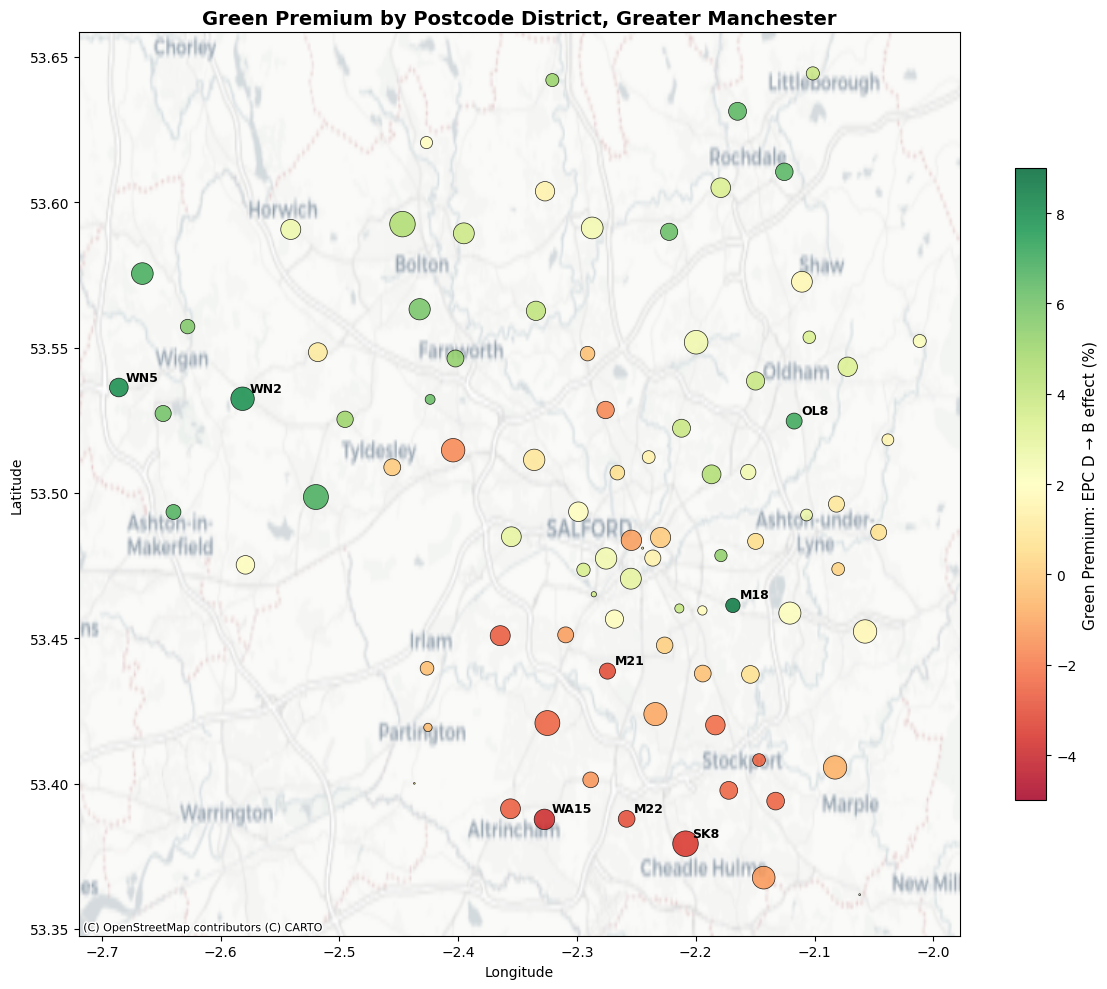

In [ ]:
!pip install contextily --quiet
import matplotlib.pyplot as plt
import contextily as ctx




fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    district_map_data['longitude'],
    district_map_data['latitude'],
    c=district_map_data['green_premium_pct'],
    s=district_map_data['n_properties'] / 20,
    cmap='RdYlGn',
    vmin=-5, vmax=9,
    edgecolors='black',
    linewidths=0.5,
    alpha=0.85,
    zorder=3
)

top_and_bottom = pd.concat([
    district_map_data.nlargest(4, 'green_premium_pct'),
    district_map_data.nsmallest(4, 'green_premium_pct')
])

for _, row in top_and_bottom.iterrows():
    ax.annotate(
        row['postcode_district'],
        (row['longitude'], row['latitude']),
        fontsize=9,
        fontweight='bold',
        xytext=(5, 5),
        textcoords='offset points'
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Green Premium: EPC D → B effect (%)', fontsize=11)

ax.set_title('Green Premium by Postcode District, Greater Manchester', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, zorder=0)

plt.tight_layout()

SAVE_PATH = '/content/drive/MyDrive/Dissertation/Charts/phase5_green_premium_map.png'
plt.savefig(SAVE_PATH, dpi=200, bbox_inches='tight')
print(f"Map saved to: {SAVE_PATH}")
plt.show()

In [ ]:
from xgboost import XGBRegressor

df_idx['adjusted_price_per_sqm'] = df_idx['adjusted_price'] / df_idx['total_floor_area']
df_idx['log_price_per_sqm'] = np.log(df_idx['adjusted_price_per_sqm'])

y_train_sqm = df_idx.loc[X_train_adj.index, 'log_price_per_sqm']
y_test_sqm = df_idx.loc[X_test_adj.index, 'log_price_per_sqm']

best_params_adj = joblib.load(f'{MODELS_FOLDER}/xgb_best_params_adjusted.pkl')

xgb_model_sqm = XGBRegressor(**best_params_adj)
xgb_model_sqm.fit(X_train_adj, y_train_sqm)

train_r2 = xgb_model_sqm.score(X_train_adj, y_train_sqm)
test_r2 = xgb_model_sqm.score(X_test_adj, y_test_sqm)

print(f"Price-per-sqm model trained.")
print(f"Train R-squared: {train_r2:.4f}")
print(f"Test R-squared: {test_r2:.4f}")

Price-per-sqm model trained.
Train R-squared: 0.7732
Test R-squared: 0.6475


In [ ]:
prop_type_groups_sqm = {
    'Detached': X_train_adj['prop_type_D'] == 1,
    'Semi-detached': X_train_adj['prop_type_S'] == 1,
    'Terraced': X_train_adj['prop_type_T'] == 1,
    'Other': X_train_adj['prop_type_O'] == 1,
}
prop_type_groups_sqm['Flat'] = ~(
    X_train_adj['prop_type_D'].astype(bool) |
    X_train_adj['prop_type_S'].astype(bool) |
    X_train_adj['prop_type_T'].astype(bool) |
    X_train_adj['prop_type_O'].astype(bool)
)

print("Price-per-sqm model: EPC effect (D -> B) by property type:")
for label, mask in prop_type_groups_sqm.items():
    X_group = X_train_adj[mask]
    if len(X_group) < 30:
        print(f"  {label}: n={len(X_group)} (too few to estimate reliably)")
        continue
    X_group_d = X_group.copy(); X_group_d['epc_numeric'] = 4
    X_group_b = X_group.copy(); X_group_b['epc_numeric'] = 6
    pred_d = xgb_model_sqm.predict(X_group_d).mean()
    pred_b = xgb_model_sqm.predict(X_group_b).mean()
    pct = (np.exp(pred_b - pred_d) - 1) * 100
    print(f"  {label}: {pct:+.2f}%  (n={len(X_group):,})")

Price-per-sqm model: EPC effect (D -> B) by property type:
  Detached: -0.75%  (n=39,155)
  Semi-detached: -1.29%  (n=93,768)
  Terraced: +4.71%  (n=97,486)
  Other: +3.14%  (n=9,332)
  Flat: +2.05%  (n=49,606)


In [ ]:
def bootstrap_epc_effect(X_group, model, n_bootstrap=500, grade_from=4, grade_to=6, seed=42):
    rng = np.random.default_rng(seed)
    n = len(X_group)
    effects = []
    for i in range(n_bootstrap):
        resample_idx = rng.integers(0, n, size=n)
        X_resample = X_group.iloc[resample_idx].copy()

        X_from = X_resample.copy(); X_from['epc_numeric'] = grade_from
        X_to = X_resample.copy(); X_to['epc_numeric'] = grade_to

        pred_from = model.predict(X_from).mean()
        pred_to = model.predict(X_to).mean()
        effects.append((np.exp(pred_to - pred_from) - 1) * 100)

    effects = np.array(effects)
    mean_effect = effects.mean()
    ci_low, ci_high = np.percentile(effects, [2.5, 97.5])
    return mean_effect, ci_low, ci_high

detached_mask = X_train_adj['prop_type_D'] == 1
semi_mask = X_train_adj['prop_type_S'] == 1

X_detached = X_train_adj[detached_mask]
X_semi = X_train_adj[semi_mask]

mean_d, low_d, high_d = bootstrap_epc_effect(X_detached, xgb_model_adj)
mean_s, low_s, high_s = bootstrap_epc_effect(X_semi, xgb_model_adj)

print("Bootstrapped D -> B effect, raw price model:")
print(f"Detached:      mean {mean_d:+.2f}%   95% CI [{low_d:+.2f}%, {high_d:+.2f}%]   (n={len(X_detached):,})")
print(f"Semi-detached: mean {mean_s:+.2f}%   95% CI [{low_s:+.2f}%, {high_s:+.2f}%]   (n={len(X_semi):,})")

KeyboardInterrupt: 

In [ ]:
lat_step_deg = 10 / 111
mean_lat_rad = np.radians(df_idx['latitude'].mean())
lon_step_deg = 10 / (111 * np.cos(mean_lat_rad))

min_lat = df_idx['latitude'].min()
min_lon = df_idx['longitude'].min()

df_idx['grid_lat_idx'] = ((df_idx['latitude'] - min_lat) // lat_step_deg).astype(int)
df_idx['grid_lon_idx'] = ((df_idx['longitude'] - min_lon) // lon_step_deg).astype(int)
df_idx['grid_id'] = df_idx['grid_lat_idx'].astype(str) + '_' + df_idx['grid_lon_idx'].astype(str)

grid_counts = df_idx['grid_id'].value_counts()
valid_grids = grid_counts[grid_counts >= 30].index

print(f"Total distinct 10km grid cells: {df_idx['grid_id'].nunique()}")
print(f"Grid cells with at least 30 sales: {len(valid_grids)}")
print(f"Rows falling in valid grid cells: {df_idx[df_idx['grid_id'].isin(valid_grids)].shape[0]:,}")
print(f"\nProperties per valid grid cell (summary):")
print(grid_counts[grid_counts >= 30].describe())

Total distinct 10km grid cells: 19
Grid cells with at least 30 sales: 18
Rows falling in valid grid cells: 361,671

Properties per valid grid cell (summary):
count       18.000000
mean     20092.833333
std      16293.465476
min        867.000000
25%       7408.250000
50%      17503.500000
75%      30125.750000
max      64223.000000
Name: count, dtype: float64


In [ ]:
df_idx['postcode_sector'] = df_idx['postcode'].str.extract(r'^([A-Z]+\d+[A-Z]?\s?\d)')

sector_counts = df_idx['postcode_sector'].value_counts()
valid_sectors = sector_counts[sector_counts >= 30].index

print(f"Total distinct postcode sectors: {df_idx['postcode_sector'].nunique()}")
print(f"Sectors with at least 30 sales: {len(valid_sectors)}")
print(f"Rows falling in valid sectors: {df_idx[df_idx['postcode_sector'].isin(valid_sectors)].shape[0]:,}")
print(f"\nProperties per valid sector (summary):")
print(sector_counts[sector_counts >= 30].describe())

Total distinct postcode sectors: 363
Sectors with at least 30 sales: 354
Rows falling in valid sectors: 361,607

Properties per valid sector (summary):
count     354.000000
mean     1021.488701
std       543.076778
min        34.000000
25%       685.000000
50%      1009.500000
75%      1288.500000
max      4661.000000
Name: count, dtype: float64


In [ ]:
from sklearn.cluster import KMeans

coords = df_idx[['latitude', 'longitude']].values

n_clusters = 89
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_idx['spatial_cluster'] = kmeans.fit_predict(coords)

cluster_counts = df_idx['spatial_cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts >= 30].index

print(f"Total clusters requested: {n_clusters}")
print(f"Clusters with at least 30 sales: {len(valid_clusters)}")
print(f"Rows falling in valid clusters: {df_idx[df_idx['spatial_cluster'].isin(valid_clusters)].shape[0]:,}")
print(f"\nProperties per valid cluster (summary):")
print(cluster_counts[cluster_counts >= 30].describe())

Total clusters requested: 89
Clusters with at least 30 sales: 89
Rows falling in valid clusters: 361,684

Properties per valid cluster (summary):
count       89.000000
mean      4063.865169
std       1498.039319
min       1451.000000
25%       3185.000000
50%       4006.000000
75%       4624.000000
max      13256.000000
Name: count, dtype: float64


In [ ]:
n_clusters_fine = 354

kmeans_fine = KMeans(n_clusters=n_clusters_fine, random_state=42, n_init=10)
df_idx['spatial_cluster_fine'] = kmeans_fine.fit_predict(coords)

cluster_fine_counts = df_idx['spatial_cluster_fine'].value_counts()
valid_clusters_fine = cluster_fine_counts[cluster_fine_counts >= 30].index

print(f"Clusters requested: {n_clusters_fine}")
print(f"Clusters with at least 30 sales: {len(valid_clusters_fine)}")
print(f"Rows falling in valid clusters: {df_idx[df_idx['spatial_cluster_fine'].isin(valid_clusters_fine)].shape[0]:,}")
print(f"\nProperties per valid cluster (summary):")
print(cluster_fine_counts[cluster_fine_counts >= 30].describe())

KeyboardInterrupt: 

Tried ensembling Random Forest with XGBoost, per Phil's earlier suggestion. First attempt used mismatched targets (nominal RF + adjusted XGBoost), not valid. Retrained RF properly on the adjusted target: RF alone MAPE 19.46%, XGBoost alone 18.80%, ensemble (average of both) 18.73% — a small but real improvement. Saved as random_forest_adjusted.pkl. Recommend using the ensemble for the app.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_adj = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf_adj.fit(X_train_adj, y_train_adj)

rf_adj_preds_log = rf_adj.predict(X_test_adj)
ensemble_adj_preds_log = (xgb_preds_log + rf_adj_preds_log) / 2

rf_adj_preds_realterms = np.exp(rf_adj_preds_log) / test_adj_factors
ensemble_adj_preds_realterms = np.exp(ensemble_adj_preds_log) / test_adj_factors

rf_adj_mape = mape(y_test_realterms, rf_adj_preds_realterms)
ensemble_adj_mape = mape(y_test_realterms, ensemble_adj_preds_realterms)

print(f"XGBoost alone MAPE: {xgb_mape:.2f}%")
print(f"Random Forest (adjusted target) alone MAPE: {rf_adj_mape:.2f}%")
print(f"XGBoost + Random Forest (adjusted) ensemble MAPE: {ensemble_adj_mape:.2f}%")

XGBoost alone MAPE: 18.80%
Random Forest (adjusted target) alone MAPE: 19.46%
XGBoost + Random Forest (adjusted) ensemble MAPE: 18.73%


In [ ]:
joblib.dump(rf_adj, f'{MODELS_FOLDER}/random_forest_adjusted.pkl')
print("Random Forest (adjusted) saved.")

Random Forest (adjusted) saved.


In [ ]:
xgb_test_preds_log = xgb_model_adj.predict(X_test_adj)
rf_test_preds_log = rf_adj.predict(X_test_adj)
ensemble_test_preds_log = (xgb_test_preds_log + rf_test_preds_log) / 2

ensemble_test_preds_realterms = np.exp(ensemble_test_preds_log) / test_adj_factors
y_test_realterms_check = np.exp(y_test_adj) / test_adj_factors

abs_pct_error = np.abs((y_test_realterms_check - ensemble_test_preds_realterms) / y_test_realterms_check) * 100

error_df = pd.DataFrame({
    'actual_price': y_test_realterms_check,
    'predicted_price': ensemble_test_preds_realterms,
    'abs_pct_error': abs_pct_error
}, index=X_test_adj.index)

print(f"Mean absolute percentage error (sanity check, should match 18.73%): {error_df['abs_pct_error'].mean():.2f}%")
print(f"\nError distribution:")
print(error_df['abs_pct_error'].describe())
print(f"\nProperties with error > 50%: {(error_df['abs_pct_error'] > 50).sum():,} ({(error_df['abs_pct_error'] > 50).mean()*100:.1f}%)")
print(f"Properties with error > 100%: {(error_df['abs_pct_error'] > 100).sum():,} ({(error_df['abs_pct_error'] > 100).mean()*100:.1f}%)")

Mean absolute percentage error (sanity check, should match 18.73%): 18.73%

Error distribution:
count    72337.000000
mean        18.731431
std         24.855251
min          0.000015
25%          5.763752
50%         12.731411
75%         23.272632
max       1337.165660
Name: abs_pct_error, dtype: float64

Properties with error > 50%: 4,357 (6.0%)
Properties with error > 100%: 979 (1.4%)


In [ ]:
worst_errors = error_df.sort_values('abs_pct_error', ascending=False).head(30)
worst_with_context = df_idx.loc[worst_errors.index, [
    'postcode', 'postcode_district', 'price', 'total_floor_area', 'price_per_sqm',
    'property_type_ppd', 'epc_numeric', 'is_new_build', 'match_tier', 'sale_year'
]].join(worst_errors)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(worst_with_context)

        postcode postcode_district   price  total_floor_area  price_per_sqm  \
203764    M1 3NJ                M1   25000                49     510.204082   
154745   SK8 5DB               SK8   20000                29     689.655172   
293872    M5 4AE                M5   10000                15     666.666667   
202359   M28 2QP               M28   68200               132     516.666667   
180174    M4 6BG                M4   40000                73     547.945205   
296902   M20 2HN               M20  115000               220     522.727273   
228490   M20 3LJ               M20   35000                57     614.035088   
226511   M33 2DL               M33   38315                70     547.357143   
287880    M8 0SE                M8   22500                44     511.363636   
199841   OL3 7DB               OL3   45000                49     918.367347   
269374   BL9 6RX               BL9   43000                80     537.500000   
335091   M20 2ED               M20   65000          

In [ ]:
print("ppd_category values in the worst 30 errors:")
print(df_idx.loc[worst_errors.index, 'ppd_category'].value_counts())

print("\nppd_category values across the FULL test set (for comparison):")
print(df_idx.loc[X_test_adj.index, 'ppd_category'].value_counts())

print("\nproperty_type_ppd 'O' rate in worst 30 errors:",
      (df_idx.loc[worst_errors.index, 'property_type_ppd'] == 'O').mean() * 100, "%")
print("property_type_ppd 'O' rate across full test set:",
      (df_idx.loc[X_test_adj.index, 'property_type_ppd'] == 'O').mean() * 100, "%")

ppd_category values in the worst 30 errors:
ppd_category
B    28
A     2
Name: count, dtype: int64

ppd_category values across the FULL test set (for comparison):
ppd_category
A    59549
B    12788
Name: count, dtype: int64

property_type_ppd 'O' rate in worst 30 errors: 83.33333333333334 %
property_type_ppd 'O' rate across full test set: 3.185091999944703 %


In [ ]:
category_a_mask = df_idx.loc[X_test_adj.index, 'ppd_category'] == 'A'

mape_category_a_only = error_df.loc[category_a_mask.values, 'abs_pct_error'].mean()
mape_category_b_only = error_df.loc[~category_a_mask.values, 'abs_pct_error'].mean()

print(f"MAPE on standard sales only (category A): {mape_category_a_only:.2f}%")
print(f"MAPE on non-standard sales only (category B): {mape_category_b_only:.2f}%")
print(f"\nCategory A: {category_a_mask.sum():,} properties")
print(f"Category B: {(~category_a_mask).sum():,} properties")

MAPE on standard sales only (category A): 16.59%
MAPE on non-standard sales only (category B): 28.68%

Category A: 59,549 properties
Category B: 12,788 properties


In [ ]:
sector_effects = []

for sector in valid_sectors:
    sector_mask = df_idx['postcode_sector'] == sector
    sector_idx = df_idx[sector_mask].index
    sector_idx_in_train = sector_idx.intersection(X_train_adj.index)

    if len(sector_idx_in_train) < 30:
        continue

    X_sector = X_train_adj.loc[sector_idx_in_train]

    X_d = X_sector.copy(); X_d['epc_numeric'] = 4
    X_b = X_sector.copy(); X_b['epc_numeric'] = 6

    pred_d = xgb_model_adj.predict(X_d).mean()
    pred_b = xgb_model_adj.predict(X_b).mean()
    pct_effect = (np.exp(pred_b - pred_d) - 1) * 100

    mean_lat = df_idx.loc[sector_idx, 'latitude'].mean()
    mean_lon = df_idx.loc[sector_idx, 'longitude'].mean()

    sector_effects.append({
        'postcode_sector': sector,
        'green_premium_pct': pct_effect,
        'n_properties': len(X_sector),
        'latitude': mean_lat,
        'longitude': mean_lon
    })

sector_map_data = pd.DataFrame(sector_effects)
print(f"Sectors with mappable data: {len(sector_map_data)}")
print(sector_map_data.sort_values('green_premium_pct', ascending=False).head(10))
print("\nLowest 10:")
print(sector_map_data.sort_values('green_premium_pct').head(10))

Sectors with mappable data: 354
    postcode_sector  green_premium_pct  n_properties   latitude  longitude
82            WN5 9          18.737089          1043  53.537526  -2.664600
57            WN6 7          18.562149          1158  53.553942  -2.647216
310           BL3 5          13.744783           324  53.570013  -2.452225
175           WN1 3          12.219536           809  53.548957  -2.617474
196           WN5 0          12.150204           755  53.545199  -2.676750
298           OL4 1          11.600614           420  53.539030  -2.091846
265          OL12 0          11.416125           539  53.628819  -2.157417
39            WN7 4          10.961533          1239  53.494895  -2.537670
97            M18 8          10.738277          1001  53.466074  -2.166412
91            WN2 3          10.306120          1026  53.531067  -2.580286

Lowest 10:
    postcode_sector  green_premium_pct  n_properties   latitude  longitude
349           OL1 1         -18.405651            57  53

Sector-level map saved to: /content/drive/MyDrive/Dissertation/Charts/phase5_green_premium_map_sectors.png


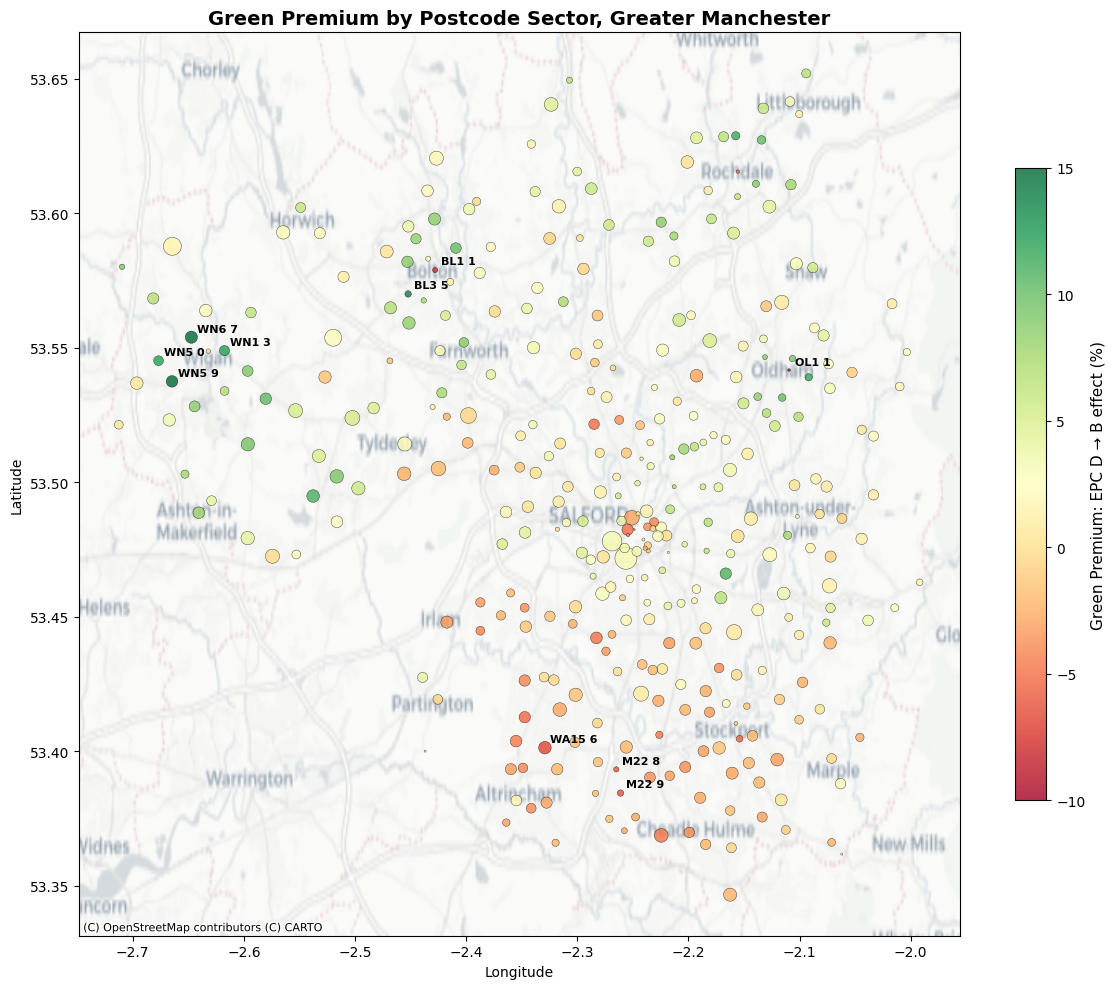

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    sector_map_data['longitude'],
    sector_map_data['latitude'],
    c=sector_map_data['green_premium_pct'],
    s=sector_map_data['n_properties'] / 15,
    cmap='RdYlGn',
    vmin=-10, vmax=15,
    edgecolors='black',
    linewidths=0.3,
    alpha=0.8,
    zorder=3
)

top_and_bottom = pd.concat([
    sector_map_data.nlargest(5, 'green_premium_pct'),
    sector_map_data.nsmallest(5, 'green_premium_pct')
])

for _, row in top_and_bottom.iterrows():
    ax.annotate(
        row['postcode_sector'],
        (row['longitude'], row['latitude']),
        fontsize=8,
        fontweight='bold',
        xytext=(4, 4),
        textcoords='offset points'
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Green Premium: EPC D → B effect (%)', fontsize=11)

ax.set_title('Green Premium by Postcode Sector, Greater Manchester', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, zorder=0)

plt.tight_layout()

SAVE_PATH = '/content/drive/MyDrive/Dissertation/Charts/phase5_green_premium_map_sectors.png'
plt.savefig(SAVE_PATH, dpi=200, bbox_inches='tight')
print(f"Sector-level map saved to: {SAVE_PATH}")
plt.show()